# Importando

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [4]:
df = pd.read_csv('table_ABSENTEEISM.csv', sep=';', encoding='UTF-8')

In [5]:
df.head()

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours
0,11,26,7,3,1,289,36,13,33,"239,554",...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,"239,554",...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,"239,554",...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,"239,554",...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,"239,554",...,0,1,2,1,0,1,90,172,30,2


# Análise de Correlação/Associaçao

In [6]:
df_numerico = df[['Transportation_expense','Distance_from_Residence_to_Work','Service_time','Age','Hit_target','Education','Day_of_the_week','Seasons','Reason_for_absence','Son','Social_drinker','Social_smoker','Pet','Weight','Height','Body_mass_index','Absenteeism_time_in_hours']].copy()

In [7]:
matriz = df_numerico.corr(method='spearman')

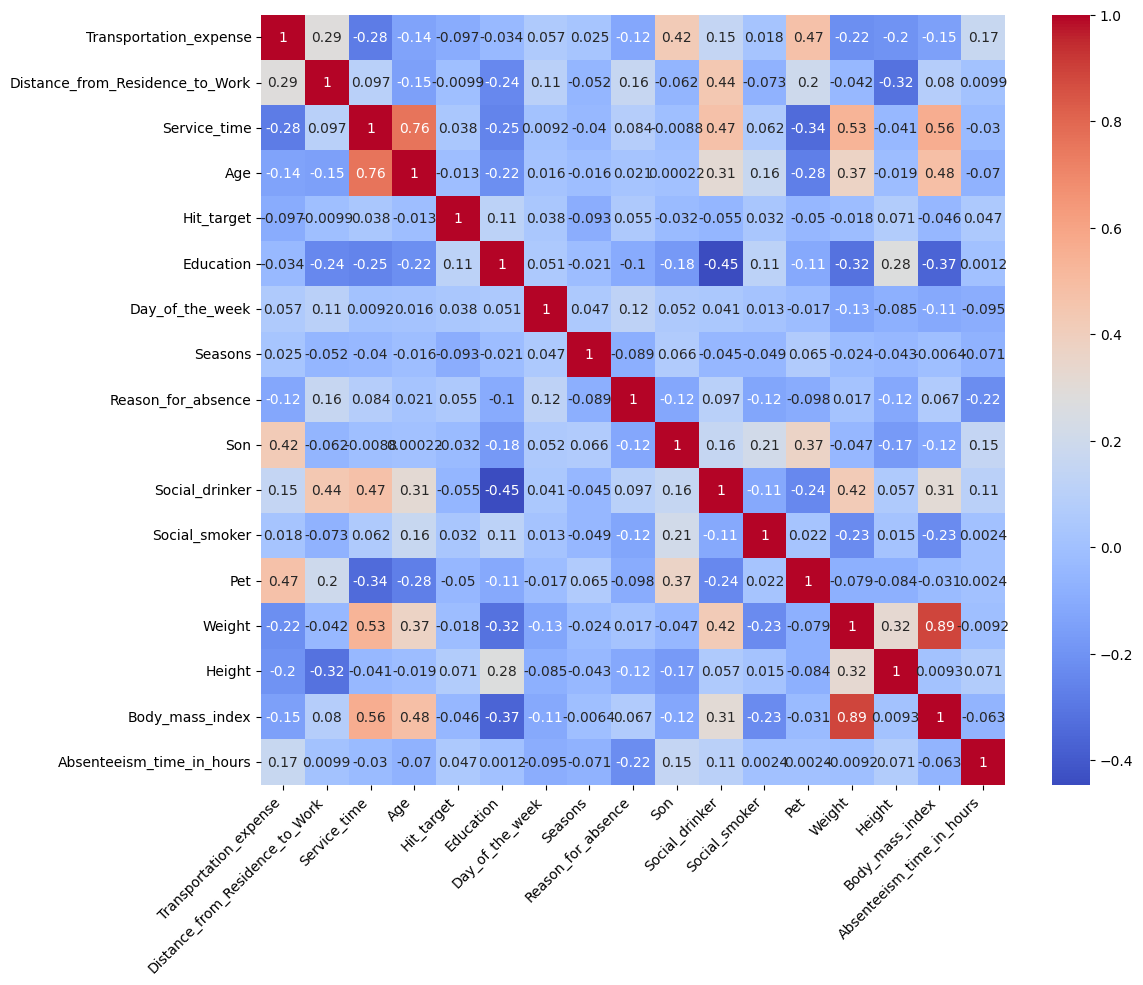

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(matriz, 
            cmap='coolwarm',
            annot=True,
            )

plt.savefig('figures/Imagens Bivariadas/Heatmap.png', 
            dpi=300,
            bbox_inches = 'tight')

plt.xticks(rotation=45, ha='right') 

plt.show()

A análise de correlação de Spearman indicou associações muito fracas entre as variáveis numéricas e o tempo de absenteísmo. O maior coeficiente observado foi para o gasto com transporte (ρ = 0,17), seguido pelo número de filhos (ρ = 0,15). Os resultados sugerem que o absenteísmo não pode ser explicado adequadamente por uma única variável isolada, indicando a necessidade de análises multivariadas para compreender melhor o fenômeno.

As correlações fortes observadas no mapa de calor foram: Age × Service_time, Weight × Body_mass_index, o que é condizente com o esperado. Tais associações indicam que essas variáveis compartilham parte considerável da informação explicativa e devem ser avaliadas cuidadosamente antes da modelagem de regressão.

## Análise multicolinearidade com VIF

In [9]:
X = df_numerico.drop(
    columns=['Absenteeism_time_in_hours']
)

In [10]:
X_const = add_constant(X)

In [11]:
vif = pd.DataFrame()

In [12]:
vif["Variavel"] = X_const.columns

In [13]:
vif["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
    ]

In [14]:
vif = vif.sort_values("VIF", ascending=False)

In [15]:
vif = vif.drop(vif.index[0])

In [ ]:
# Tabela VIF

print(vif)

                           Variavel         VIF
14                           Weight  176.900879
16                  Body_mass_index  161.650427
15                           Height   32.042071
3                      Service_time    3.420289
4                               Age    2.549386
2   Distance_from_Residence_to_Work    2.546864
11                   Social_drinker    2.469647
13                              Pet    1.834339
1            Transportation_expense    1.763723
6                         Education    1.446051
10                              Son    1.394024
12                    Social_smoker    1.285507
9                Reason_for_absence    1.121110
7                   Day_of_the_week    1.080784
5                        Hit_target    1.059028
8                           Seasons    1.045739


A avaliação da multicolinearidade foi realizada por meio do Fator de Inflação da Variância (VIF). Observou-se valores extremamente elevados para Peso (VIF = 174,88), Altura (VIF = 31,69) e Índice de Massa Corporal (VIF = 159,56). Esse resultado era esperado, uma vez que o Índice de Massa Corporal é calculado diretamente a partir das variáveis Peso e Altura, caracterizando uma relação matemática de dependência entre elas. Dessa forma, a inclusão simultânea dessas variáveis em modelos de regressão pode gerar instabilidade nos coeficientes estimados e dificultar a interpretação dos resultados.

Observando os demais vifs:

Variável	VIF
Service_time	3.39
Age	2.50

Mesmo com correlação de 0,76 entre elas, os VIFs estão baixos. Ou seja, a correlação entre Age e Service_time não é suficientemente forte para causar um problema sério de multicolinearidade. O restante das variáveis também apresentou VIF inferior a 5, indicando baixa redundância entre os preditores.

## Analisando a relação de Absenteismo com as Estações e do Dia da semana visualmente

In [18]:
estacoes = {
    1: 'Verão',
    2: 'Outono',
    3: 'Inverno',
    4: 'Primavera'
}

In [19]:
df['Estacao_Nome'] = df['Seasons'].map(estacoes)

In [20]:
dias = {
    2: 'Segunda',
    3: 'Terça',
    4: 'Quarta',
    5: 'Quinta',
    6: 'Sexta'
}

In [21]:
df['Dia_Semana_Nome'] = df['Day_of_the_week'].map(dias)

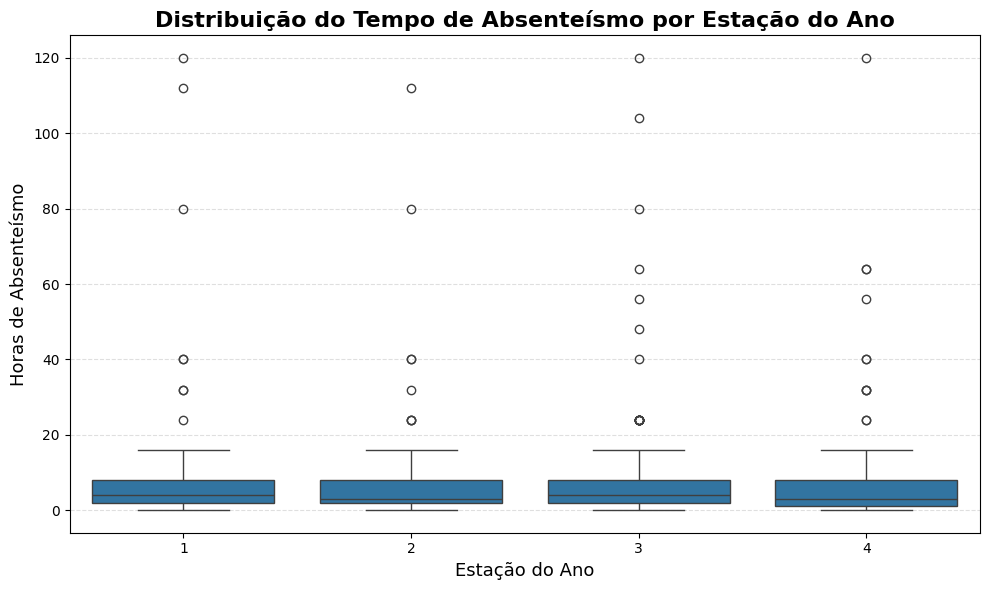

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Seasons',
    y='Absenteeism_time_in_hours',
)

plt.title(
    'Distribuição do Tempo de Absenteísmo por Estação do Ano',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Estação do Ano',
    fontsize=13
)

plt.ylabel(
    'Horas de Absenteísmo',
    fontsize=13
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    'figures/Imagens Bivariadas/Boxplot_Seasons.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

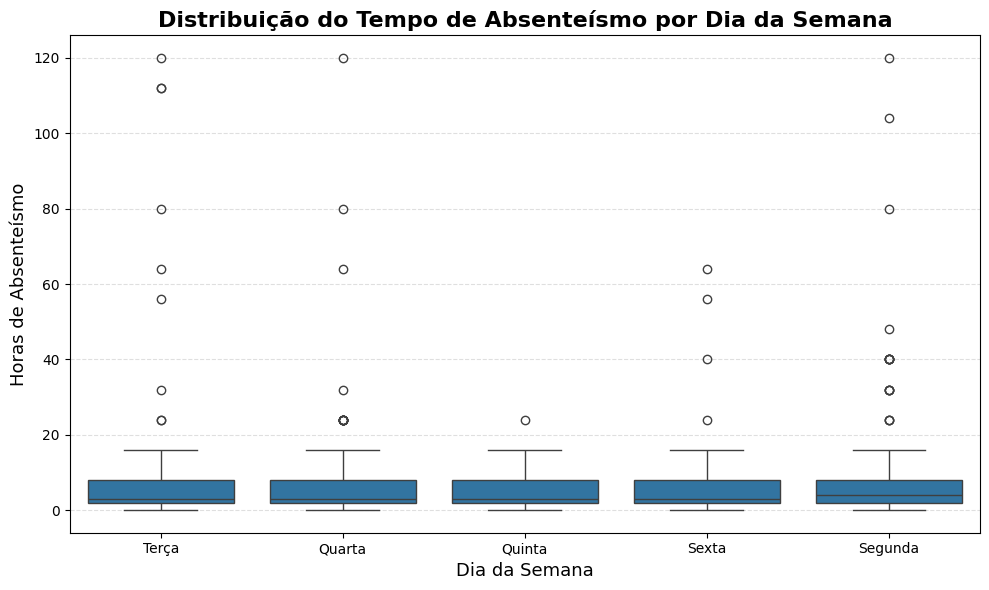

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Dia_Semana_Nome',
    y='Absenteeism_time_in_hours',
)

plt.title(
    'Distribuição do Tempo de Absenteísmo por Dia da Semana',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Dia da Semana',
    fontsize=13
)

plt.ylabel(
    'Horas de Absenteísmo',
    fontsize=13
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    'figures/Imagens Bivariadas/Boxplot_DiaSemana.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Na análise gráfica por dia da semana e estações do ano por meio de boxplots, não foram observadas diferenças relevantes entre as distribuições, uma vez que as medianas, amplitudes interquartílicas e dispersões apresentaram comportamentos semelhantes. Dessa forma, não há evidências visuais de que a estação do ano e o dia da semana exerçam influência significativa sobre o tempo de ausência dos funcionários.

In [24]:
from scipy.stats import kruskal

In [25]:
grupos = [
    grupo['Absenteeism_time_in_hours'].values
    for _, grupo in df.groupby('Seasons')
]

In [26]:
estatistica, p = kruskal(*grupos)

In [ ]:
# Teste Kruskal-Wallis

print(f'Estatística = {estatistica:.4f}')
print(f'p-valor = {p:.4f}')

Estatística = 7.8033
p-valor = 0.0503


Para avaliar se a estação do ano influencia o tempo de absenteísmo, foi aplicado o teste não paramétrico de Kruskal-Wallis. O teste produziu estatística H = 7,80 e p-valor = 0,0503. Considerando um nível de significância de 5%, não foi possível rejeitar a hipótese nula de igualdade entre as distribuições. Entretanto, o p-valor encontrado ficou muito próximo do limiar de significância, sugerindo a existência de uma possível influência sazonal que merece investigação adicional.

In [28]:
df.groupby('Estacao_Nome')['Absenteeism_time_in_hours'].agg(
    ['count','mean','median','std']
).round(2)

,count,mean,median,std
Estacao_Nome,,,,
Inverno,183,8.15,4.0,15.15
Outono,192,6.00,3.0,11.06
Primavera,195,6.35,3.0,12.47
Verão,170,7.30,4.0,14.50


Observando a média e mediana pelas estações, os maiores tempos médios e medianos de absenteísmo ocorreram durante o inverno e o verão. Esse comportamento sugere uma possível influência sazonal sobre as ausências, ainda que a evidência estatística não tenha sido suficiente para rejeitar a hipótese nula ao nível de significância adotado.

# PCA

In [29]:
variaveis_pca = [
    'Transportation_expense',
    'Distance_from_Residence_to_Work',
    'Service_time',
    'Age',
    'Hit_target',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet',
    'Body_mass_index'
]

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [31]:
X = df[variaveis_pca]

In [32]:
X_pad = StandardScaler().fit_transform(X)

In [33]:
pca = PCA()

In [34]:
pca.fit(X_pad)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [36]:
variancia_acumulada = np.cumsum(
    pca.explained_variance_ratio_
)

In [ ]:
# Tabela de Variância Acumulada

print(variancia_acumulada)

[0.24988991 0.43945084 0.55858462 0.65100944 0.73687742 0.81223352
 0.87359686 0.91509959 0.95043075 0.98269907 1.        ]


Observando os dados: 0.24988991; o primeiro componente explica apenas 24,99% dos dados, ou seja, não existe uma única dimensão dominante nos dados. Os cinco primeiros componentes principais foram capazes de explicar aproximadamente 74% da variabilidade total dos dados. Quando considerados os seis primeiros componentes, a variância explicada acumulada ultrapassa 81%, indicando que uma parcela substancial da informação original pode ser preservada com redução moderada da dimensionalidade.


In [38]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(variaveis_pca))],
    index=variaveis_pca
)

In [39]:
loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Transportation_expense,-0.207,0.493,0.118,-0.100,-0.022,-0.116,0.455,0.541,-0.326,-0.226,0.141
Distance_from_Residence_to_Work,0.104,0.454,-0.269,0.368,-0.030,0.473,0.094,-0.337,-0.325,-0.018,-0.350
Service_time,0.518,-0.114,0.144,0.128,-0.048,0.185,0.205,-0.182,-0.220,-0.051,0.720
Age,0.447,-0.118,0.339,-0.101,0.198,-0.152,0.280,-0.127,0.082,-0.533,-0.462
Hit_target,-0.066,-0.113,0.108,0.887,0.046,-0.407,0.004,0.131,0.013,-0.018,-0.007
Education,-0.298,-0.343,0.001,0.056,-0.168,0.209,0.764,-0.134,0.239,0.231,-0.078
Son,-0.026,0.355,0.511,-0.097,-0.380,-0.371,0.006,-0.441,-0.060,0.348,-0.047
Social_drinker,0.344,0.384,-0.085,0.106,-0.322,0.112,0.015,0.248,0.732,0.003,0.043
Social_smoker,-0.054,-0.013,0.679,0.109,0.248,0.538,-0.172,0.278,0.036,0.237,-0.093
Pet,-0.264,0.342,0.009,0.010,0.672,-0.061,0.092,-0.369,0.356,-0.081,0.284


A interpretação dos loadings revelou que o primeiro componente principal esteve associado principalmente à idade, tempo de serviço e índice de massa corporal, caracterizando um eixo relacionado à experiência profissional e características demográficas dos funcionários. O segundo componente concentrou variáveis ligadas ao deslocamento e contexto familiar, como despesas de transporte, distância residência-trabalho, número de filhos e animais de estimação. Já o terceiro componente foi fortemente influenciado pelo hábito de fumar e pela quantidade de filhos, enquanto o quarto componente refletiu predominantemente o indicador de desempenho organizacional (Hit Target).

## Projetar os dados em 2 componentes - Método do Cotovelo

In [40]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [41]:
pca_2 = PCA(n_components=2)

In [42]:
X_pca = pca_2.fit_transform(X_pad)

In [43]:
print(X_pca.shape)

(740, 2)


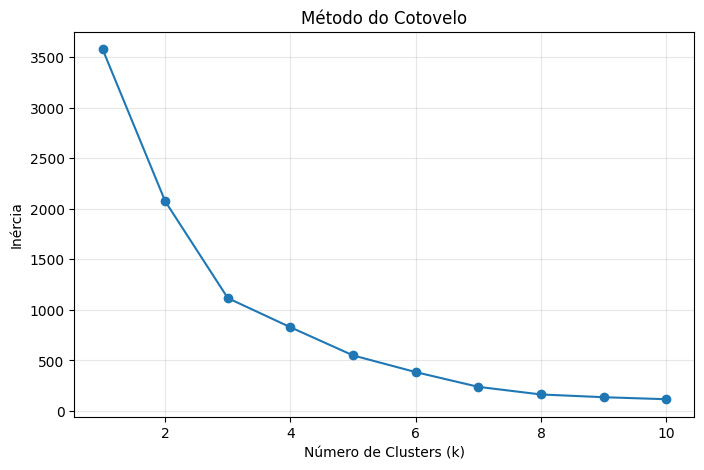

In [ ]:
# Método do cotovelo - para calcular o número adequado de agrupamentos no PCA

inercia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercia,
    marker='o'
)

plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')

plt.grid(alpha=0.3)

plt.savefig(
    'figures/Imagens Bivariadas/Método do Cotovelo.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

O método do cotovelo não apresentou um ponto de inflexão claramente definido. Assim, utilizou-se o coeficiente de Silhouette para determinar o número adequado de agrupamentos.

In [45]:
# coeficiente de Silhouette

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    print(f'k={k}: {score:.3f}')

k=2: 0.443
k=3: 0.520
k=4: 0.548
k=5: 0.589
k=6: 0.623
k=7: 0.667
k=8: 0.719
k=9: 0.701
k=10: 0.689


O maior valor foi obtido para k=8 (Silhouette = 0,719), indicando uma separação muito satisfatória entre os grupos. Dessa forma, optou-se pela utilização de oito clusters na etapa de segmentação dos funcionários.

In [48]:
# Ajuste do modelo

kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_pca)

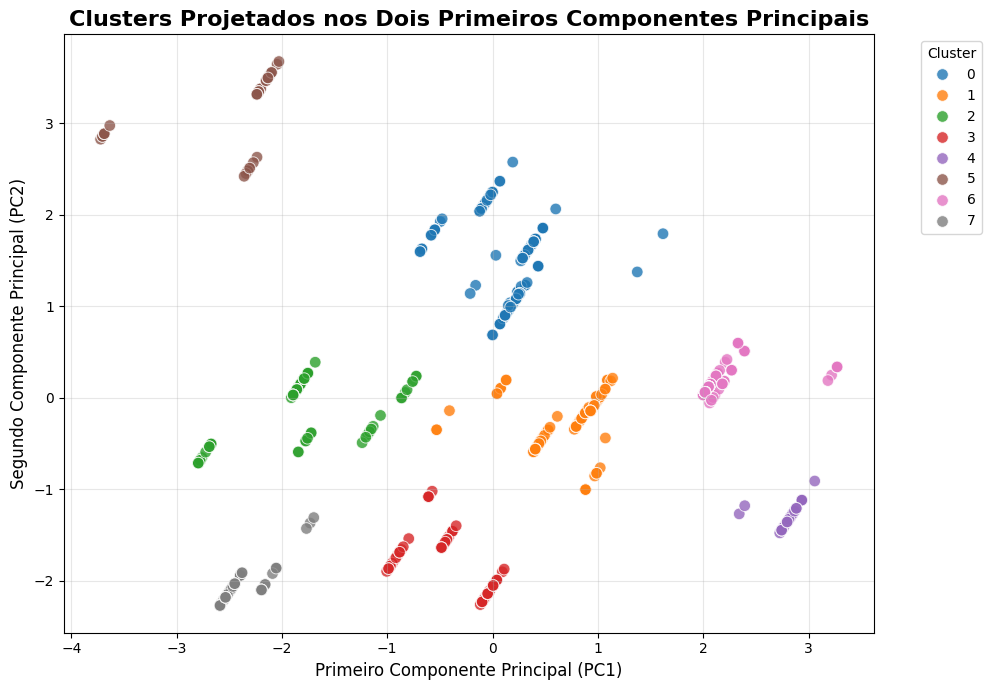

In [65]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Cluster'],
    palette='tab10',
    s=70,
    alpha=0.8
)

plt.title(
    'Clusters Projetados nos Dois Primeiros Componentes Principais',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Primeiro Componente Principal (PC1)', fontsize=12)
plt.ylabel('Segundo Componente Principal (PC2)', fontsize=12)

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'figures/Imagens Bivariadas/Clusters Projetados nos Dois Primeiros Componentes Principais.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

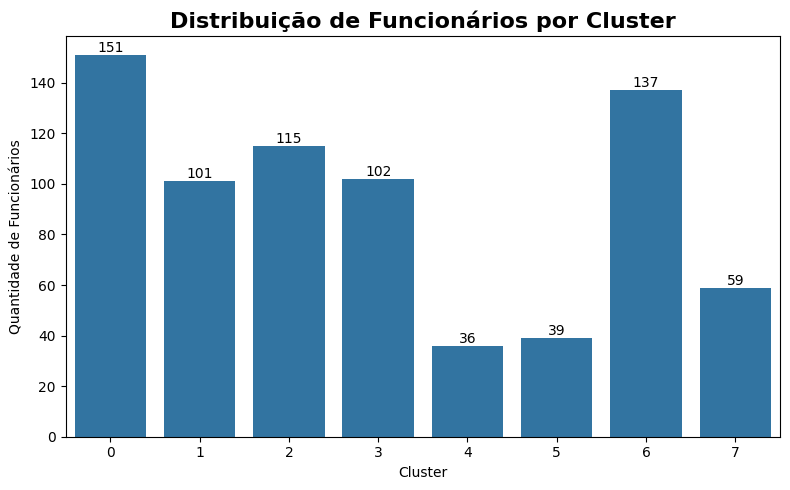

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Cluster',
)

plt.title(
    'Distribuição de Funcionários por Cluster',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Cluster')
plt.ylabel('Quantidade de Funcionários')

for p in plt.gca().patches:
    plt.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'figures/Imagens Bivariadas/Distribuição de Funcionários por Cluster.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

A Figura X apresenta a quantidade de funcionários pertencentes a cada um dos oito clusters identificados pelo algoritmo K-Means. Observa-se que os grupos apresentaram tamanhos relativamente equilibrados, variando entre 36 e 151 observações. A ausência de clusters extremamente pequenos indica que o algoritmo não se limitou a identificar apenas casos isolados ou outliers, mas sim agrupamentos representativos da população analisada.

# Regressão Linear

O objetivo desta etapa é construir um modelo de regressão linear múltipla capaz de explicar a variabilidade do tempo de absenteísmo dos funcionários a partir das características pessoais, profissionais e comportamentais disponíveis no conjunto de dados.

In [66]:
variaveis = [
    'Transportation_expense',
    'Distance_from_Residence_to_Work',
    'Service_time',
    'Age',
    'Hit_target',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet',
    'Body_mass_index'
]

Removidas as variáveis 'Weight' e 'Height' devido a multicolinearidade indentificada com IMC.

In [67]:
import statsmodels.api as sm

In [68]:
X = df[variaveis]
y = df['Absenteeism_time_in_hours']

In [69]:
X = sm.add_constant(X)

In [70]:
modelo = sm.OLS(y, X).fit()

In [85]:
display(modelo.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     Absenteeism_time_in_hours   R-squared:                       0.043
Model:                                   OLS   Adj. R-squared:                  0.029
Method:                        Least Squares   F-statistic:                     2.993
Date:                       Fri, 12 Jun 2026   Prob (F-statistic):           0.000658
Time:                               11:51:48   Log-Likelihood:                -2949.8
No. Observations:                        740   AIC:                             5924.
Df Residuals:                            728   BIC:                             5979.
Df Model:                                 11                                         
Covariance Type:                   nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.4383     13.554      0.032      0.974     -26.172      27.049
Transportation_expense              0.0064      0.009      0.691      0.490      -0.012       0.025
Distance_from_Residence_to_Work    -0.1395      0.043     -3.245      0.001      -0.224      -0.055
Service_time                        0.1386      0.196      0.706      0.480      -0.247       0.524
Age                                 0.1139      0.114      0.999      0.318      -0.110       0.338
Hit_target                          0.1356      0.130      1.045      0.296      -0.119       0.391
Education                          -1.0360      0.852     -1.216      0.224      -2.708       0.636
Son                                 0.7904      0.516      1.532      0.126      -0.222       1.803
Social_drinker                      2.9318      1.300      2.256      0.024       0.380       5.484
Social_smoker                      -2.9632      2.033     -1.457      0.145      -6.955       1.029
Pet                                 0.2358      0.470      0.502      0.616      -0.686       1.158
Body_mass_index                    -0.3975      0.153     -2.592      0.010      -0.699      -0.096
==============================================================================
Omnibus:                      816.237   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            43137.604
Skew:                           5.396   Prob(JB):                         0.00
Kurtosis:                      38.813   Cond. No.                     7.14e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

R² = 0,043
O modelo explica aproximadamente 4,3% da variabilidade observada no tempo de absenteísmo.

R² Ajustado = 0,029
Após considerar o número de variáveis explicativas, apenas 2,9% da variabilidade é explicada. O que sujere que as variáveis disponíveis possuem capacidade limitada para prever diretamente as horas de ausência.

Prob(F-statistic) = 0,000658

Como: p < 0,05
O modelo é estatisticamente significativo de forma global, indicando que pelo menos uma variável explicativa contribui para explicar o absenteísmo.

## Pressupostos da Regressão Linear

### Normalidade

In [86]:
pred = modelo.fittedvalues
res = modelo.resid

In [88]:
from scipy.stats import shapiro

In [ ]:
# Teste de Shapiro-Wilk
shapiro(res)

ShapiroResult(statistic=np.float64(0.4836139388711538), pvalue=np.float64(1.029373686803449e-41))

H₀: os resíduos seguem distribuição normal.
H₁: os resíduos não seguem distribuição normal.

Estatística = 0,4836
p-valor = 1,03 × 10⁻⁴¹

como p < 0,05, rejeitamos H₀
Os resíduos do modelo não apresentam distribuição normal.

O teste de Shapiro-Wilk foi aplicado para avaliar a normalidade dos resíduos do modelo. O resultado obtido (W = 0,484; p < 0,001) indicou rejeição da hipótese nula de normalidade. Esse resultado sugere que os resíduos apresentam distribuição significativamente diferente da normal, evidenciando assimetria e possível presença de valores extremos. Tal comportamento já havia sido sugerido pelas estatísticas de Jarque-Bera e pela elevada curtose observada no ajuste inicial do modelo.

### Homocedasticidade

In [77]:
from statsmodels.stats.diagnostic import het_breuschpagan

In [78]:
bp = het_breuschpagan(
    res,
    modelo.model.exog
)

In [79]:
# Teste de Breusch-Pagan.

print('LM Statistic:', bp[0])
print('LM p-value:', bp[1])

LM Statistic: 28.87659036437344
LM p-value: 0.0023721993522263546


LM Statistic = 28,88
p = 0,0024

Hipóteses:

H₀: variância constante dos resíduos (homocedasticidade)
H₁: variância não constante (heterocedasticidade)

Como:

p = 0,0024 < 0,05

rejeitamos H₀.
Há evidências de heterocedasticidade.

## Ajuste no modelo inicial

Foi ajustado um modelo inicial, os pressupostos foram avaliados e, diante da violação da normalidade e homocedasticidade, realizou-se uma transformação logarítmica da variável resposta para obtenção de um modelo mais adequado.

In [92]:
df['Abs_log'] = np.log1p(df['Absenteeism_time_in_hours'])

In [99]:
variaveis = [
    'Transportation_expense',
    'Distance_from_Residence_to_Work',
    'Service_time',
    'Age',
    'Hit_target',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet',
    'Body_mass_index'
]

In [100]:
X = df[variaveis]
X = sm.add_constant(X)

In [101]:
y = df['Abs_log']

In [102]:
modelo_log = sm.OLS(y, X).fit()

In [103]:
display(modelo_log.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Abs_log   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     3.370
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           0.000146
Time:                        12:28:22   Log-Likelihood:                -920.42
No. Observations:                 740   AIC:                             1865.
Df Residuals:                     728   BIC:                             1920.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.3973      0.873      0.455      0.649      -1.317       2.111
Transportation_expense              0.0013      0.001      2.195      0.028       0.000       0.002
Distance_from_Residence_to_Work    -0.0068      0.003     -2.454      0.014      -0.012      -0.001
Service_time                        0.0086      0.013      0.677      0.499      -0.016       0.033
Age                                -0.0090      0.007     -1.220      0.223      -0.023       0.005
Hit_target                          0.0159      0.008      1.896      0.058      -0.001       0.032
Education                          -0.0016      0.055     -0.030      0.976      -0.109       0.106
Son                                 0.0647      0.033      1.947      0.052      -0.001       0.130
Social_drinker                      0.2335      0.084      2.789      0.005       0.069       0.398
Social_smoker                      -0.1101      0.131     -0.840      0.401      -0.367       0.147
Pet                                -0.0154      0.030     -0.509      0.611      -0.075       0.044
Body_mass_index                    -0.0133      0.010     -1.345      0.179      -0.033       0.006
==============================================================================
Omnibus:                       75.620   Durbin-Watson:                   1.791
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              128.107
Skew:                           0.678   Prob(JB):                     1.52e-28
Kurtosis:                       4.522   Cond. No.                     7.14e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

W = 0,965

R² = 0.048

R² Ajustado = 0.034

A transformação logarítmica reduziu drasticamente a assimetria dos resíduos e aproximou sua distribuição da normalidade.

In [ ]:
# Homocedasticidade

het_breuschpagan(
    modelo_log.resid,
    modelo_log.model.exog
)

(np.float64(40.99925306388694),
 np.float64(2.4107553620100238e-05),
 np.float64(3.8818343524781893),
 np.float64(1.7894870959879615e-05))

p = 0,000024
A transformação logarítmica não foi suficiente para corrigir a heterocedasticidade dos resíduos.
Dessa forma, os resultados devem ser interpretados com cautela, reconhecendo as limitações inerentes à estrutura dos dados de absenteísmo.

In [ ]:
# Cook's Distance

influence = modelo_log.get_influence()

cooks = influence.cooks_distance[0]

limite = 4/len(df)

In [105]:
# Cook's Distance

print("Limite:", limite)
print("Observações acima do limite:")
print(sum(cooks > limite))

Limite: 0.005405405405405406
Observações acima do limite:
55


A análise da Distância de Cook foi utilizada para identificar observações potencialmente influentes no ajuste do modelo. Utilizando como critério o limite 4/n, correspondente a 0,0054, foram identificadas 55 observações acima desse valor. Esses registros representam aproximadamente 7,4% da amostra e estão associados, em grande parte, a funcionários com valores de absenteísmo substancialmente superiores à média. Apesar da presença dessas observações influentes, sua proporção não foi considerada suficiente para justificar a exclusão de registros, sendo mantidos no modelo para preservar a representatividade dos dados.